Importing Dependencies

In [42]:
pip install pandas numpy scikit-learn gensim matplotlib seaborn tensorflow nltk

Note: you may need to restart the kernel to use updated packages.


In [65]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [44]:
df = pd.read_csv(r"C:\Users\Asus\Downloads\IMDB Dataset.csv\IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [45]:
df.shape

(50000, 2)

In [46]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


Basic Dataset Inspection

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


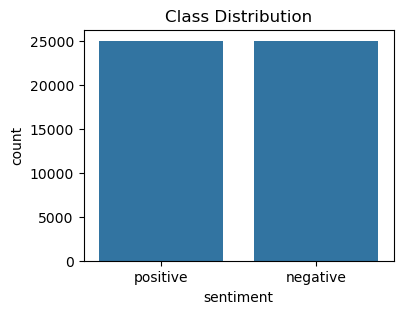

In [48]:
print(df['sentiment'].value_counts())

plt.figure(figsize=(4, 3))
sns.countplot(x='sentiment', data=df)
plt.title("Class Distribution")
plt.show()

Convert Labels to Binary

In [49]:
df['label'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df = df.drop('sentiment', axis=1)


In [58]:
df.head()

,review,label
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


Text Cleaning

In [63]:
def clean_text(text):
    text = text.lower()
    
    # remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,label,clean_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...


Train-Test Split

In [67]:
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (40000,)
Test size: (10000,)


Save Processed Data

In [71]:
X_train.to_csv(r"C:\Users\Asus\Downloads\IMDB Dataset.csv\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\Asus\Downloads\IMDB Dataset.csv\X_test.csv", index=False)
y_train.to_csv(r"C:\Users\Asus\Downloads\IMDB Dataset.csv\y_train.csv", index=False)
y_test.to_csv(r"C:\Users\Asus\Downloads\IMDB Dataset.csv\y_test.csv", index=False)

Other Important Libraries

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

TF-IDF Vectorization

In [77]:
tfidf = TfidfVectorizer(
    max_features=5000,      # limit vocab size
    ngram_range=(1,2),      # unigrams + bigrams
    min_df=5                # ignore rare words
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (40000, 5000)
Test TF-IDF shape: (10000, 5000)


Train Logistic Regression

In [80]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [88]:
y_pred = lr.predict(X_test_tfidf)
y_pred

array([0, 1, 1, ..., 0, 1, 0], dtype=int64)

Evaluation Metrics

In [91]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8926
Precision: 0.8871794871794871
Recall: 0.8996
F1 Score: 0.8933465739821251




Confusion Matrix

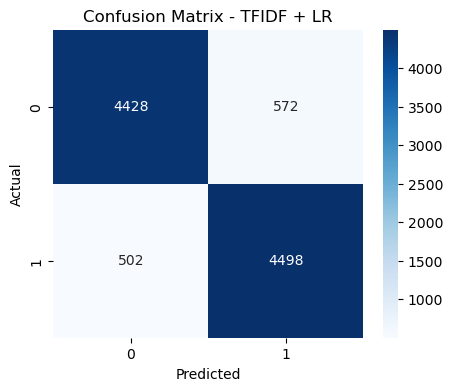

In [93]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TFIDF + LR")
plt.show()

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      5000
           1       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



Now we move from sparse representation (TF-IDF) to dense embeddings.

We will use:

Gensim Word2Vec

In [98]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [105]:
from gensim.models import Word2Vec
from tqdm import tqdm

In [107]:
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

In [147]:
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

In [111]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 72755


In [113]:
def get_sentence_vector(tokens, model, vector_size):
    vectors = []
    
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(vector_size)
    
    return np.mean(vectors, axis=0) 

X_train_w2v = np.array([
    get_sentence_vector(tokens, w2v_model, 100)
    for tokens in tqdm(X_train_tokens)
])

X_test_w2v = np.array([
    get_sentence_vector(tokens, w2v_model, 100)
    for tokens in tqdm(X_test_tokens)
])

print(X_train_w2v.shape)
print(X_test_w2v.shape)

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:06<00:00, 1517.47it/s]

(40000, 100)
(10000, 100)


In [115]:
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

In [117]:
accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
precision_w2v = precision_score(y_test, y_pred_w2v)
recall_w2v = recall_score(y_test, y_pred_w2v)
f1_w2v = f1_score(y_test, y_pred_w2v)

print("Word2Vec + LR Results")
print("Accuracy:", accuracy_w2v)
print("Precision:", precision_w2v)
print("Recall:", recall_w2v)
print("F1:", f1_w2v)

Word2Vec + LR Results
Accuracy: 0.8627
Precision: 0.8613269575612672
Recall: 0.8646
F1: 0.8629603752869548


In [119]:
from gensim.models import FastText

In [121]:
fasttext_model = FastText(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [123]:
print("FastText Vocabulary size:", len(fasttext_model.wv))

FastText Vocabulary size: 72755


In [125]:
X_train_ft = np.array([
    get_sentence_vector(tokens, fasttext_model, 100)
    for tokens in tqdm(X_train_tokens)
])

X_test_ft = np.array([
    get_sentence_vector(tokens, fasttext_model, 100)
    for tokens in tqdm(X_test_tokens)
])

100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:09<00:00, 1104.39it/s]


In [127]:
lr_ft = LogisticRegression(max_iter=1000)
lr_ft.fit(X_train_ft, y_train)

y_pred_ft = lr_ft.predict(X_test_ft)

In [129]:
accuracy_ft = accuracy_score(y_test, y_pred_ft)
precision_ft = precision_score(y_test, y_pred_ft)
recall_ft = recall_score(y_test, y_pred_ft)
f1_ft = f1_score(y_test, y_pred_ft)

print("FastText + LR Results")
print("Accuracy:", accuracy_ft)
print("Precision:", precision_ft)
print("Recall:", recall_ft)
print("F1:", f1_ft)

FastText + LR Results
Accuracy: 0.8627
Precision: 0.8616151545363908
Recall: 0.8642
F1: 0.8629056415376934


In [131]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [133]:
max_vocab = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [135]:
print(X_train_pad.shape)

(40000, 200)


In [137]:
embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((max_vocab, embedding_dim))

for word, i in word_index.items():
    if i < max_vocab:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

In [151]:
model = Sequential([
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True   # freeze embeddings first
    ),
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │       2,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [153]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 220ms/step - accuracy: 0.5488 - loss: 0.6848 - val_accuracy: 0.5270 - val_loss: 0.6868
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 110s 220ms/step - accuracy: 0.5703 - loss: 0.6775 - val_accuracy: 0.5669 - val_loss: 0.6755
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 114s 228ms/step - accuracy: 0.5625 - loss: 0.6814 - val_accuracy: 0.5244 - val_loss: 0.6904
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.6874 - loss: 0.5574 - val_accuracy: 0.8583 - val_loss: 0.3398
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 112s 224ms/step - accuracy: 0.8952 - loss: 0.2773 - val_accuracy: 0.8785 - val_loss: 0.3037


In [155]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("LSTM + Word2Vec Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8786 - loss: 0.2958
LSTM + Word2Vec Accuracy: 0.878600001335144


In [149]:
covered = 0
for word in tokenizer.word_index:
    if word in w2v_model.wv:
        covered += 1

print("Coverage:", covered / len(tokenizer.word_index))

Coverage: 0.9999946505755981


In [157]:
embedding_matrix_ft = np.zeros((max_vocab, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < max_vocab:
        if word in fasttext_model.wv:
            embedding_matrix_ft[i] = fasttext_model.wv[word]

In [159]:
model_ft = Sequential([
    Embedding(
        input_dim=max_vocab,
        output_dim=embedding_dim,
        weights=[embedding_matrix_ft],
        input_length=max_len,
        trainable=True
    ),
    LSTM(128),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_ft.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [161]:
history_ft = model_ft.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 226ms/step - accuracy: 0.5556 - loss: 0.6883 - val_accuracy: 0.5329 - val_loss: 0.6905
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 111s 222ms/step - accuracy: 0.5810 - loss: 0.6619 - val_accuracy: 0.8381 - val_loss: 0.4257
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 231ms/step - accuracy: 0.8627 - loss: 0.3425 - val_accuracy: 0.8668 - val_loss: 0.3148
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 114s 228ms/step - accuracy: 0.9177 - loss: 0.2290 - val_accuracy: 0.8829 - val_loss: 0.2947
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 114s 227ms/step - accuracy: 0.9485 - loss: 0.1616 - val_accuracy: 0.8752 - val_loss: 0.3396


In [163]:
loss_ft, accuracy_ft_lstm = model_ft.evaluate(X_test_pad, y_test)

print("LSTM + FastText Test Accuracy:", accuracy_ft_lstm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8770 - loss: 0.3333
LSTM + FastText Test Accuracy: 0.8769999742507935


In [165]:
y_pred_prob_ft = model_ft.predict(X_test_pad)
y_pred_ft_lstm = (y_pred_prob_ft > 0.5).astype("int32")

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step


In [167]:
y_pred_ft_lstm = y_pred_ft_lstm.flatten()

In [169]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred_ft_lstm)
precision = precision_score(y_test, y_pred_ft_lstm)
recall = recall_score(y_test, y_pred_ft_lstm)
f1 = f1_score(y_test, y_pred_ft_lstm)

print("FastText + LSTM Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

FastText + LSTM Results
Accuracy: 0.877
Precision: 0.8540570999248686
Recall: 0.9094
F1: 0.8808601317318868


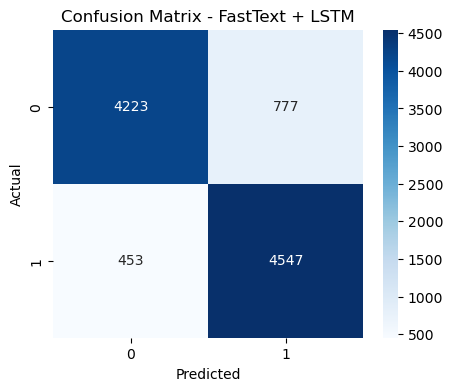

In [171]:
cm = confusion_matrix(y_test, y_pred_ft_lstm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - FastText + LSTM")
plt.show()

Final Model Comparison

| Model           | Accuracy   | F1         |
| --------------- | ---------- | ---------- |
| TF-IDF + LR     | **0.8926** | **0.8933** |
| Word2Vec + LR   | 0.8627     | 0.8630     |
| FastText + LR   | 0.8627     | 0.8629     |
| LSTM + Word2Vec | 0.8786     | ~0.878     |
| LSTM + FastText | 0.8770     | 0.8809     |


In [175]:
from sklearn.manifold import TSNE

In [177]:
# Combine embeddings and labels
df_test_w2v = pd.DataFrame(X_test_w2v)
df_test_w2v['label'] = y_test.values

# Take 1000 positive and 1000 negative
pos_samples = df_test_w2v[df_test_w2v['label'] == 1].sample(1000, random_state=42)
neg_samples = df_test_w2v[df_test_w2v['label'] == 0].sample(1000, random_state=42)

df_sample = pd.concat([pos_samples, neg_samples])

X_sample = df_sample.drop('label', axis=1).values
y_sample = df_sample['label'].values

In [179]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

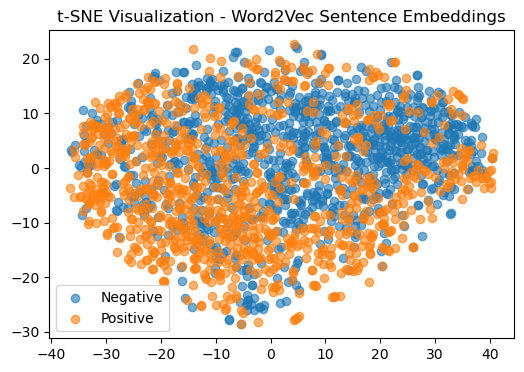

In [183]:
plt.figure(figsize=(6,4))

for label in [0, 1]:
    indices = y_sample == label
    plt.scatter(
        X_tsne[indices, 0],
        X_tsne[indices, 1],
        label="Negative" if label == 0 else "Positive",
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Visualization - Word2Vec Sentence Embeddings")
plt.show()

In [185]:
# Combine embeddings and labels
df_test_ft = pd.DataFrame(X_test_ft)
df_test_ft['label'] = y_test.values

# Take 1000 positive and 1000 negative
pos_samples = df_test_w2v[df_test_w2v['label'] == 1].sample(1000, random_state=42)
neg_samples = df_test_w2v[df_test_w2v['label'] == 0].sample(1000, random_state=42)

df_sample = pd.concat([pos_samples, neg_samples])

X_sample = df_sample.drop('label', axis=1).values
y_sample = df_sample['label'].values

In [187]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

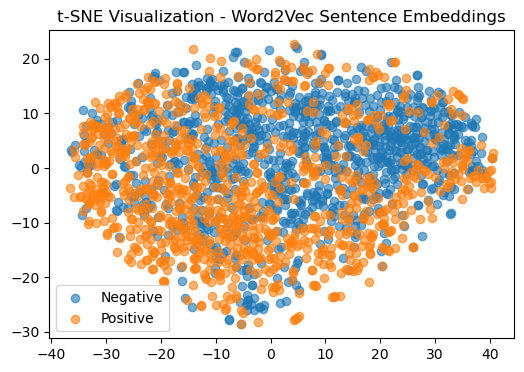

In [189]:
plt.figure(figsize=(6,4))

for label in [0, 1]:
    indices = y_sample == label
    plt.scatter(
        X_tsne[indices, 0],
        X_tsne[indices, 1],
        label="Negative" if label == 0 else "Positive",
        alpha=0.6
    )

plt.legend()
plt.title("t-SNE Visualization - Word2Vec Sentence Embeddings")
plt.show()

In [191]:
y_pred_baseline = lr.predict(X_test_tfidf)

In [193]:
misclassified_indices = np.where(y_pred_baseline != y_test)[0]
len(misclassified_indices)

1074

In [195]:
error_df = pd.DataFrame({
    "review": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_baseline
})

error_df = error_df.iloc[misclassified_indices]
error_df.head(10)

,review,true_label,predicted_label
1,the story of the bride fair is an amusing and ...,0,1
14,little quentin seems to have mastered the art ...,0,1
16,just watched this movie on dvd and thought the...,1,0
28,the movie gung ho the story of carlsons makin ...,0,1
42,in order to enjoy fur an imaginary portrait of...,0,1
45,i am quite a fan of novelistscreenwriter micha...,0,1
51,a recommendation gloria grahame runs the kind ...,0,1
53,tenshu is imprisoned and sentenced to death wh...,1,0
60,i just cant believe some of the comments on th...,1,0
63,ive seen branaghs hamlet branagh is too old sp...,1,0
